In [1]:
import cosima_cookbook as cc
import matplotlib.pyplot as plt
import cmocean as cm
import numpy as np
from dask.distributed import Client
from scipy.interpolate import interp1d
from gsw import sigma0, sigma1, sigma2, CT_from_pt, SA_from_SP, p_from_z

import xarray as xr
import cf_xarray as cfxr

In [2]:
client = Client(threads_per_worker = 1, memory_limit = '1400gb')

In [3]:
#panan sessions
session_p01_orig = cc.database.create_session('/home/156/wf4500/databases/access/panan01_rerun_withCSHT.db')
session_p005 = cc.database.create_session('/home/156/wf4500/databases/access/panan005_rerun.db') #panan005
session_p0025 = cc.database.create_session('/home/156/wf4500/databases/access/panan0025_final_ol01.db')


start_time = '1999-01-01'
end_time = '2001-12-31'
time_slice=slice(start_time, end_time)


In [4]:
lat_slice  = slice(-83,-59)

figdir = '/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/figs/'

In [10]:
#lets import the the density to see how it changes along isobaths
#Importing Potential temperature in panan01
MHT01_z= cc.querying.getvar('mom6-panan','T_ady',session_p01_orig,frequency='1 monthly',ncfile = '%ocean_month_z%',\
                            start_time=start_time,end_time=end_time,chunks={'xh':500,'yq':846,'time':36,'z_l':1}).sel(time = slice( start_time, end_time)).mean('time').sum('xh')
#Importing Potential temperature in panan005
MHT005_z= cc.querying.getvar('panant-005-zstar-ACCESSyr2','T_ady',session_p005,frequency='1 monthly',ncfile = '%ocean_month_z%',\
                            start_time=start_time,end_time=end_time,chunks={'xh':7200,'yq':'250gb','time':36,'z_l':'250gb'}).sel(time = slice( start_time, end_time)).mean('time').sum('xh')
#Importing Potential temperature in panan0025
MHT0025_z= cc.querying.getvar('panant-0025-zstar-ACCESSyr2','T_ady',session_p0025,frequency='1 monthly',ncfile = '%ocean_month_z%',\
                            start_time=start_time,end_time=end_time,chunks={'xh':7000,'yq':'500gb','time':24,'z_l':75}).sel(time = slice( start_time, end_time)).mean('time').sum('xh')


/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/xarray/core/dataset.py:274: UserWarning: The specified chunks separate the stored chunks along dimension "z_l" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/xarray/core/dataset.py:274: UserWarning: The specified chunks separate the stored chunks along dimension "xh" starting at index 500. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/xarray/core/dataset.py:274: UserWarning: The specified chunks separate the stored chunks along dimension "z_l" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.1

In [11]:
%%time
MHT0025_z.load()
MHT005_z.load()
MHT01_z.load()
print('Average meridional heat transport (y,z) loaded for all simulations')

2025-09-16 12:16:58,944 - distributed.worker - ERROR - failed during get data with tcp://127.0.0.1:37759 -> tcp://127.0.0.1:41259
Traceback (most recent call last):
  File "/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/tornado/iostream.py", line 861, in _read_to_buffer
    bytes_read = self.read_from_fd(buf)
  File "/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/tornado/iostream.py", line 1116, in read_from_fd
    return self.socket.recv_into(buf, len(buf))
TimeoutError: [Errno 110] Connection timed out

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/distributed/worker.py", line 1783, in get_data
    response = await comm.read(deserializers=serializers)
  File "/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/distributed/comm/

Average meridional heat transport (y,z) loaded for all simulations
CPU times: user 21min 4s, sys: 21min 42s, total: 42min 47s
Wall time: 34min 52s


In [16]:
#integrating values in depth too
MHT01=MHT01_z.sum('z_l')
MHT005=MHT005_z.sum('z_l')
MHT0025=MHT0025_z.sum('z_l')

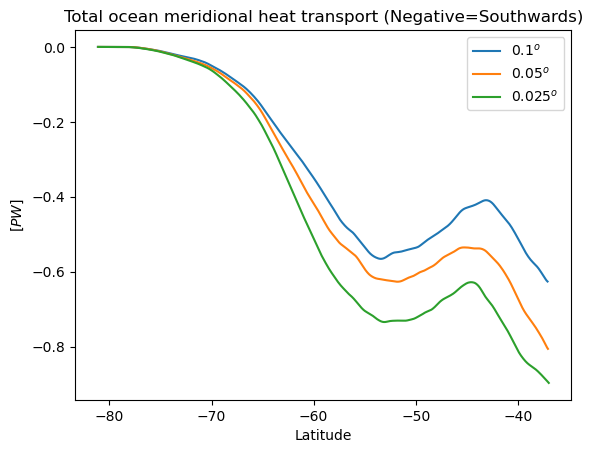

In [26]:
(1e-15 * MHT01).plot(label=r'$0.1^o$')
(1e-15 * MHT005).plot(label=r'$0.05^o$')
(1e-15 * MHT0025).plot(label=r'$0.025^o$')
plt.legend()
plt.ylabel('[$PW$]')
plt.xlabel('Latitude')
plt.title('Total ocean meridional heat transport (Negative=Southwards)')
plt.savefig('/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/figs/total_ocean_meridional_heat_transport.png',dpi=300,bbox_inches='tight')

Interestingly, the total meridional heat transport in the oceans increase from 1/10th to 1/20th to 1/40th to a quite big rate

Maybe the increase in heat transport with resolution increases the ammount of heat stored near the sea ice dge, and the heat fluxes in these regions. 

Let's save the values oh MHT, because they are quite expensive to run

In [38]:
MHT01.name = 'MHT'
MHT01 = MHT01.assign_attrs(units="PW")
MHT005.name = 'MHT'
MHT005 = MHT005.assign_attrs(units="PW")
MHT0025.name = 'MHT'
MHT0025 = MHT0025.assign_attrs(units="PW")

In [39]:
MHT01.to_netcdf('/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan01_rerun/MHT_panan01.nc')
MHT005.to_netcdf('/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan005_rerun/MHT_panan005.nc')
MHT0025.to_netcdf('/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan0025_rerun/MHT_panan0025.nc')

In [5]:
#reinporting them
MHT01 = xr.open_dataset('/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan01_rerun/MHT_panan01.nc').MHT
MHT005 = xr.open_dataset('/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan005_rerun/MHT_panan005.nc').MHT
MHT0025 = xr.open_dataset('/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan0025_rerun/MHT_panan0025.nc').MHT

How does the mean winter SST changes with latitude?

In [6]:
#lets import the SSTs
#panan01
SST01= cc.querying.getvar('mom6-panan','thetao',session_p01_orig,frequency='1 monthly',ncfile = '%ocean_month_z%',\
                            start_time=start_time,end_time=end_time,chunks={'xh':500,'yh':846,'time':36,'z_l':1}).sel(time = slice( start_time, end_time)).isel(z_l=0).groupby('time.month').mean()
#panan005
SST005= cc.querying.getvar('panant-005-zstar-ACCESSyr2','thetao',session_p005,frequency='1 monthly',ncfile = '%ocean_month_z%',\
                            start_time=start_time,end_time=end_time,chunks={'xh':7200,'yh':'250gb','time':36,'z_l':'250gb'}).sel(time = slice( start_time, end_time)).isel(z_l=0).groupby('time.month').mean()
#panan0025
SST0025= cc.querying.getvar('panant-0025-zstar-ACCESSyr2','thetao',session_p0025,frequency='1 monthly',ncfile = '%ocean_month_z%',\
                            start_time=start_time,end_time=end_time,chunks={'xh':7000,'yh':'500gb','time':24,'z_l':75}).sel(time = slice( start_time, end_time)).isel(z_l=0).groupby('time.month').mean()


/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/xarray/core/dataset.py:274: UserWarning: The specified chunks separate the stored chunks along dimension "z_l" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/xarray/core/dataset.py:274: UserWarning: The specified chunks separate the stored chunks along dimension "xh" starting at index 500. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/xarray/core/dataset.py:274: UserWarning: The specified chunks separate the stored chunks along dimension "z_l" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.1

In [7]:
Month_inds = slice(8,10)
SST01_winter =SST01.sel(month = Month_inds).mean('month')
SST005_winter =SST005.sel(month = Month_inds).mean('month')
SST0025_winter =SST0025.sel(month = Month_inds).mean('month')

In [8]:
# zonal means
ZM_SST0025_winter = SST0025_winter.mean('xh').compute()
ZM_SST005_winter = SST005_winter.mean('xh').compute()
ZM_SST01_winter = SST01_winter.mean('xh').compute()

In [9]:
#lets import the SICs
#panan01
SIC01= cc.querying.getvar('mom6-panan','siconc',session_p01_orig,frequency='1 monthly',\
                            start_time=start_time,end_time=end_time).sel(time = slice( start_time, end_time)).groupby('time.month').mean()
#panan005
SIC005= cc.querying.getvar('panant-005-zstar-ACCESSyr2','siconc',session_p005,frequency='1 monthly',\
                            start_time=start_time,end_time=end_time).sel(time = slice( start_time, end_time)).groupby('time.month').mean()
#panan0025
SIC0025= cc.querying.getvar('panant-0025-zstar-ACCESSyr2','siconc',session_p0025,frequency='1 monthly',\
                            start_time=start_time,end_time=end_time).sel(time = slice( start_time, end_time)).groupby('time.month').mean()

/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/xarray/core/dataset.py:274: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/xarray/core/dataset.py:274: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/xarray/core/dataset.py:274: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3

In [10]:
Month_inds = slice(8,10)
SIC01_winter =SIC01.sel(month = Month_inds).mean('month')
SIC005_winter =SIC005.sel(month = Month_inds).mean('month')
SIC0025_winter =SIC0025.sel(month = Month_inds).mean('month')

In [11]:
# zonal means
ZM_SIC0025_winter = SIC0025_winter.mean('xT').compute()
ZM_SIC005_winter = SIC005_winter.mean('xT').compute()
ZM_SIC01_winter = SIC01_winter.mean('xT').compute()

(-68.0, -55.0)

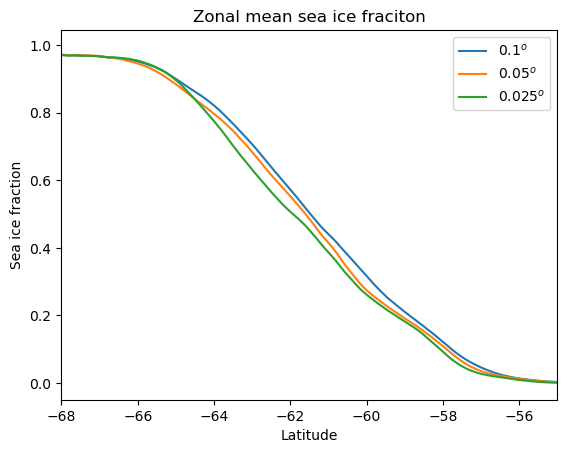

In [12]:
(ZM_SIC01_winter).plot(label=r'$0.1^o$')
(ZM_SIC005_winter).plot(label=r'$0.05^o$')
(ZM_SIC0025_winter).plot(label=r'$0.025^o$')
plt.legend()
plt.ylabel('Sea ice fraction')
plt.xlabel('Latitude')
plt.title('Zonal mean sea ice fraciton')
plt.xlim(-68,-55)
#plt.ylim(-2,2)

In [13]:
#finding the the latitude of the zonal mean 2C line
target_temp=2

#panan01           ########################################################################
diff01 = abs(ZM_SST01_winter - target_temp)
# Find the xh (longitude) where this difference is minimal
lat_closest01 = ZM_SST01_winter['yh'][diff01.argmin().item()]
temp_closest01 = ZM_SST01_winter.sel(yh=lat_closest01)

#panan005           ########################################################################
diff005 = abs(ZM_SST005_winter - target_temp)
# Find the xh (longitude) where this difference is minimal
lat_closest005 = ZM_SST005_winter['yh'][diff005.argmin().item()]
temp_closest005 = ZM_SST005_winter.sel(yh=lat_closest005)

#panan0025           ########################################################################
diff0025 = abs(ZM_SST0025_winter - target_temp)
# Find the xh (longitude) where this difference is minimal
lat_closest0025 = ZM_SST0025_winter['yh'][diff0025.argmin().item()]
temp_closest0025 = ZM_SST0025_winter.sel(yh=lat_closest0025)

How does these patterns look together and when plotted against each other?

In [14]:
# Interpolating SST for latitudinal alignment
ZM_SST01_winter_yq = ZM_SST01_winter.interp(yh = MHT01.yq)
ZM_SST005_winter_yq = ZM_SST005_winter.interp(yh = MHT005.yq)
ZM_SST0025_winter_yq = ZM_SST0025_winter.interp(yh = MHT0025.yq)

# Interpolating SIC for latitudinal alignment
ZM_SIC01_winter_yq = ZM_SIC01_winter.interp(yT = MHT01.yq)
ZM_SIC005_winter_yq = ZM_SIC005_winter.interp(yT = MHT005.yq)
ZM_SIC0025_winter_yq = ZM_SIC0025_winter.interp(yT = MHT0025.yq)

(-0.01, 0.4)

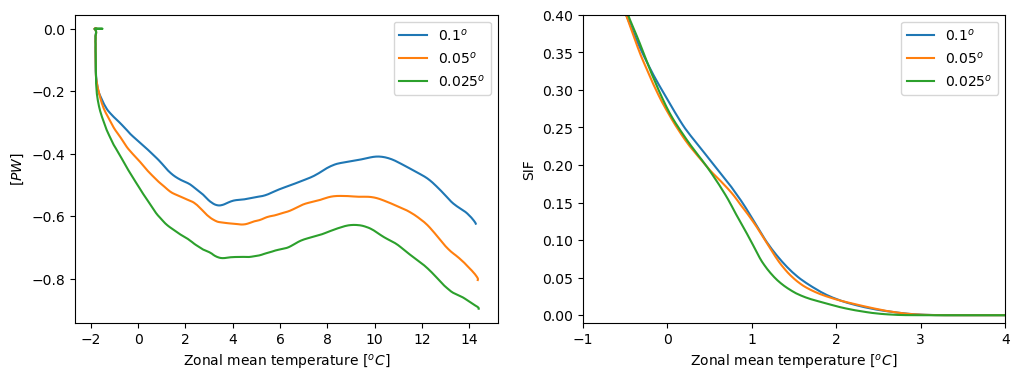

In [15]:
plt.figure(figsize = (12,4))

plt.subplot(1,2,1)
plt.plot(ZM_SST01_winter_yq,1e-15 * MHT01,label=r'$0.1^o$')
plt.plot(ZM_SST005_winter_yq,1e-15 * MHT005,label=r'$0.05^o$')
plt.plot(ZM_SST0025_winter_yq,1e-15 * MHT0025,label=r'$0.025^o$')
plt.xlabel(r'Zonal mean temperature [$^oC$]')
plt.ylabel('[$PW$]')
plt.legend()

plt.subplot(1,2,2)
plt.plot(ZM_SST01_winter_yq,ZM_SIC01_winter_yq,label=r'$0.1^o$')
plt.plot(ZM_SST005_winter_yq,ZM_SIC005_winter_yq,label=r'$0.05^o$')
plt.plot(ZM_SST0025_winter_yq,ZM_SIC0025_winter_yq,label=r'$0.025^o$')
plt.xlabel(r'Zonal mean temperature [$^oC$]')
plt.ylabel('SIF')
plt.legend()
plt.xlim(-1,4)
plt.ylim(-.01,0.4)

In [16]:
from matplotlib.patches import Polygon

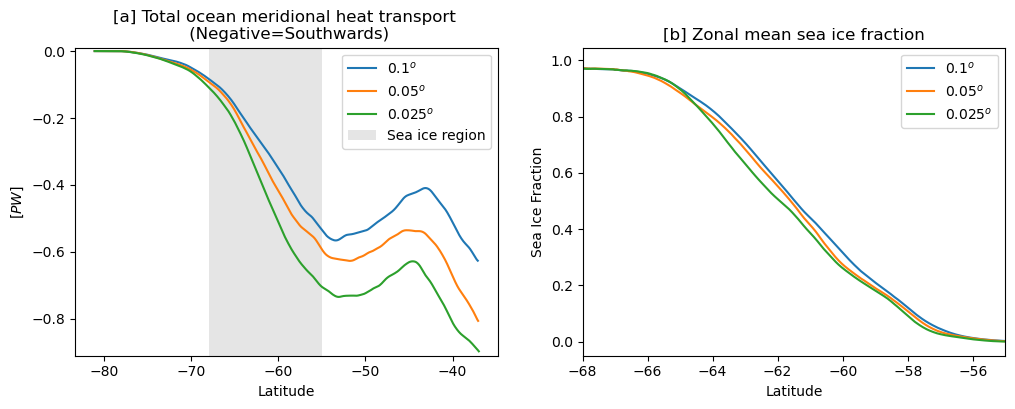

In [17]:
plt.figure(figsize = (12,4))
vertices = [(-68, -1), (-68, 0.1), (-55, 0.1), (-55, -1),(-68, -1)]
polygon = Polygon(vertices, closed=True, facecolor='grey', edgecolor=None,alpha=0.2,label='Sea ice region')

# Add the polygon to the axes
ax = plt.subplot(1,2,1)
(1e-15 * MHT01).plot(label=r'$0.1^o$')
(1e-15 * MHT005).plot(label=r'$0.05^o$')
(1e-15 * MHT0025).plot(label=r'$0.025^o$')
# plt.plot([-68,-68],[-1,0.1],color='grey',linewidth=0.5)
# plt.plot([-55,-55],[-1,0.1],color='grey',linewidth=0.5)
ax.add_patch(polygon)
plt.legend()
plt.ylim(-0.91,0.01)
plt.ylabel('[$PW$]')
plt.xlabel('Latitude')
plt.title('[a] Total ocean meridional heat transport \n (Negative=Southwards)')

plt.subplot(1,2,2)
#lat_closest01 ZM_SST01_winter
ZM_SIC01_winter.plot(label=r'$0.1^o$',color='tab:blue')
ZM_SIC005_winter.plot(label=r'$0.05^o$',color='tab:orange')
ZM_SIC0025_winter.plot(label=r'$0.025^o$',color='tab:green')
plt.legend()
plt.xlim(-68,-55)
#plt.ylim(-2,3)
plt.ylabel('Sea Ice Fraction')
plt.xlabel('Latitude')
plt.title('[b] Zonal mean sea ice fraction')
plt.savefig('/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/figs/total_ocean_meridional_heat_transport.png',dpi=300,bbox_inches='tight')

Let's cauculate the MHT divergence. For that we need to itnerpolat the values to the same grid.

In [18]:
MHT0025_into01 = MHT0025.groupby_bins('yq',bins = SST01.yh).sum().rename({'yq_bins':'yq'})
MHT005_into01 = MHT005.groupby_bins('yq',bins = SST01.yh).sum().rename({'yq_bins':'yq'})
# MHT0025_into01['yq']=MHT01
# MHT005_into01['yq']=MHT01

INFO:flox:Entering _validate_reindex: reindex is None
INFO:flox:Leaving _validate_reindex: method = None, returning None
INFO:flox:_choose_engine: Choosing 'numpy'
INFO:flox:Entering _validate_reindex: reindex is None
INFO:flox:Leaving _validate_reindex: method = None, returning None
INFO:flox:_choose_engine: Choosing 'numpy'


Text(0.5, 1.0, 'Meridional heat transport divergence\n (Negative=heat convergence)')

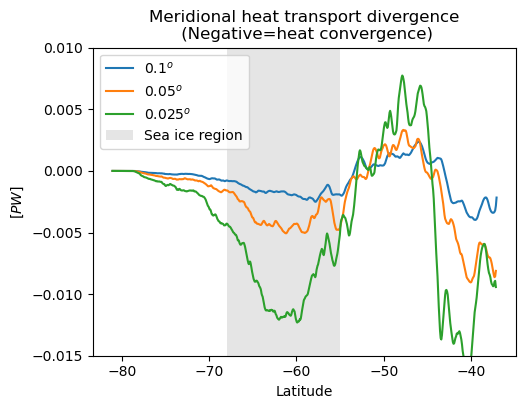

In [19]:
plt.figure(figsize = (12,4))
vertices = [(-68, -1), (-68, 0.1), (-55, 0.1), (-55, -1),(-68, -1)]
polygon = Polygon(vertices, closed=True, facecolor='grey', edgecolor=None,alpha=0.2,label='Sea ice region')

# Add the polygon to the axes
ax = plt.subplot(1,2,1)
(1e-15 * MHT01.diff('yq')).plot(label=r'$0.1^o$')
(1e-15 * MHT005_into01.diff('yq')).plot(label=r'$0.05^o$')
(1e-15 * MHT0025_into01.diff('yq')).plot(label=r'$0.025^o$')
# plt.plot([-68,-68],[-1,0.1],color='grey',linewidth=0.5)
# plt.plot([-55,-55],[-1,0.1],color='grey',linewidth=0.5)
ax.add_patch(polygon)
plt.legend()
plt.ylim(-0.015,0.01)
plt.ylabel('[$PW$]')
plt.xlabel('Latitude')
plt.title('Meridional heat transport divergence\n (Negative=heat convergence)')


#### changes in MHT with longitude

In [20]:
sea_ice_latitudes = slice(-68,-55)

In [21]:
#importing meridional heat transport without integrating it zonally
#lets import the the density to see how it changes along isobaths
#Importing Potential temperature in panan01
MHT01_SI= cc.querying.getvar('mom6-panan','T_ady',session_p01_orig,frequency='1 monthly',ncfile = '%ocean_month_z%',\
                            start_time=start_time,end_time=end_time,chunks={'xh':500,'yq':846,'time':36,'z_l':1}).sel(yq = sea_ice_latitudes).mean('yq').sel(time = slice( start_time, end_time)).mean('time').compute()
#Importing Potential temperature in panan005
MHT005_SI= cc.querying.getvar('panant-005-zstar-ACCESSyr2','T_ady',session_p005,frequency='1 monthly',ncfile = '%ocean_month_z%',\
                            start_time=start_time,end_time=end_time,chunks={'xh':7200,'yq':'250gb','time':36,'z_l':'250gb'}).sel(yq = sea_ice_latitudes).mean('yq').sel(time = slice( start_time, end_time)).mean('time').compute()
#Importing Potential temperature in panan0025
MHT0025_SI= cc.querying.getvar('panant-0025-zstar-ACCESSyr2','T_ady',session_p0025,frequency='1 monthly',ncfile = '%ocean_month_z%',\
                            start_time=start_time,end_time=end_time,chunks={'xh':7000,'yq':'500gb','time':24,'z_l':75}).sel(yq = sea_ice_latitudes).mean('yq').sel(time = slice( start_time, end_time)).mean('time').compute()


/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/xarray/core/dataset.py:274: UserWarning: The specified chunks separate the stored chunks along dimension "z_l" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/xarray/core/dataset.py:274: UserWarning: The specified chunks separate the stored chunks along dimension "xh" starting at index 500. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/xarray/core/dataset.py:274: UserWarning: The specified chunks separate the stored chunks along dimension "z_l" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.1

We also need to bun the MHT into the same long bins of the 1/10th to plot differences

In [26]:
xq = cc.querying.getvar('mom6-panan','uo',session_p01_orig,frequency='1 monthly',ncfile = '%ocean_month_z%',\
                            start_time=start_time,end_time=end_time).isel(time=0).xq.compute()

/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/xarray/core/dataset.py:274: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/xarray/core/dataset.py:274: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/xarray/core/dataset.py:274: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3

In [33]:
MHT005_SI_binned = MHT005_SI.groupby_bins('xh',bins = xq).sum().rename({'xh_bins':'xh'})
MHT0025_SI_binned = MHT0025_SI.groupby_bins('xh',bins = xq).sum().rename({'xh_bins':'xh'})
MHT005_SI_binned['xh'] = MHT01_SI.xh
MHT0025_SI_binned['xh'] = MHT01_SI.xh

INFO:flox:Entering _validate_reindex: reindex is None
INFO:flox:Leaving _validate_reindex: method = None, returning None
INFO:flox:_choose_engine: Choosing 'flox'
INFO:flox:Entering _validate_reindex: reindex is None
INFO:flox:Leaving _validate_reindex: method = None, returning None
INFO:flox:_choose_engine: Choosing 'flox'


Text(0.5, 1.0, 'Meridional heat transport under sea ice, cumulative sum along longitudes')

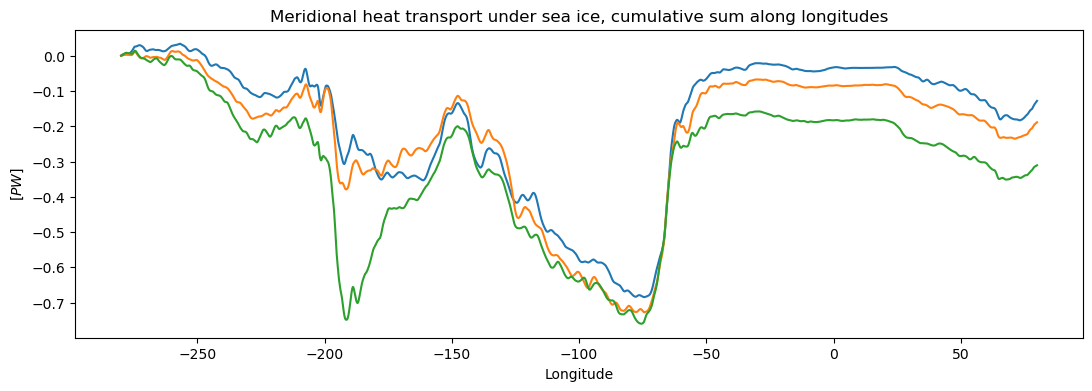

In [41]:
#vertically integrated, cumulative sum on longitudes
plt.figure(figsize=(13,4))
(1e-15 * MHT01_SI.sum('z_l')).cumsum('xh').plot()
(1e-15 * MHT005_SI_binned.sum('z_l')).cumsum('xh').plot()
(1e-15 * MHT0025_SI_binned.sum('z_l')).cumsum('xh').plot()
plt.ylabel('[$PW$]')
plt.xlabel('Longitude')
plt.title('Meridional heat transport under sea ice, cumulative sum along longitudes')

In [53]:
lon_10degbins = np.arange(-280,80,30)

INFO:flox:Entering _validate_reindex: reindex is None
INFO:flox:Leaving _validate_reindex: method = None, returning None
INFO:flox:_choose_engine: Choosing 'numpy'
INFO:flox:Entering _validate_reindex: reindex is None
INFO:flox:Leaving _validate_reindex: method = None, returning None
INFO:flox:_choose_engine: Choosing 'numpy'
INFO:flox:Entering _validate_reindex: reindex is None
INFO:flox:Leaving _validate_reindex: method = None, returning None
INFO:flox:_choose_engine: Choosing 'numpy'


Text(0.5, 1.0, 'Meridional heat transport under sea ice, in 10 degree bins')

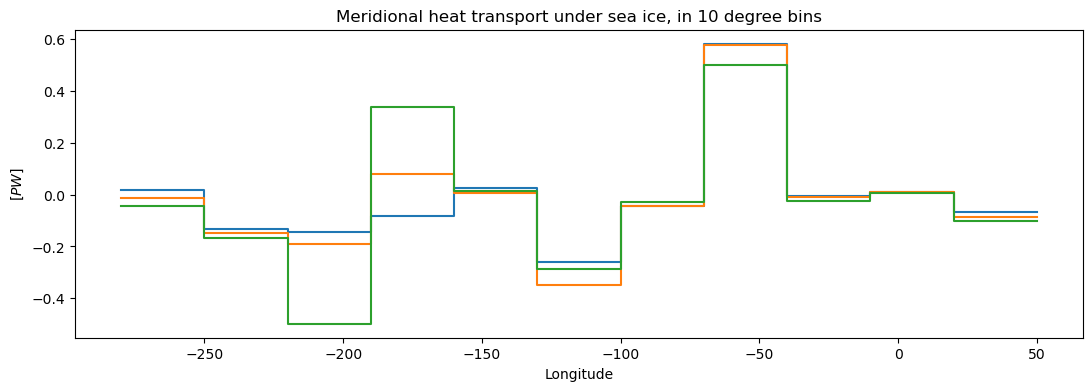

In [54]:
#LArger bins, no cumsum
plt.figure(figsize=(13,4))
(1e-15 * MHT01_SI.sum('z_l')).groupby_bins('xh',bins=lon_10degbins).sum().plot.step()
(1e-15 * MHT005_SI_binned.sum('z_l')).groupby_bins('xh',bins=lon_10degbins).sum().plot.step()
(1e-15 * MHT0025_SI_binned.sum('z_l')).groupby_bins('xh',bins=lon_10degbins).sum().plot.step()
plt.ylabel('[$PW$]')
plt.xlabel('Longitude')
plt.title('Meridional heat transport under sea ice, in 10 degree bins')

In [ ]:
Biggest chanes around the ross sea again?